In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

from sklearn.metrics import accuracy_score

MNIST dataset, which consists of images of handwritten digits, the input layer of a neural network typically has 784 neurons, not 781. This number comes from the fact that each image in the MNIST dataset is a 28x28 pixel grayscale image. To feed these images into a neural network, you would typically flatten each image into a 1D array of 28x28 = 784 elements.

The MNIST dataset is primarily used for training and testing machine learning models, particularly for tasks like handwritten digit recognition.It contains a large number of images of handwritten digits (0 to 9), each labeled with the corresponding digit. Images are grayscale and have a resolution of 28x28 pixels.It consists of 60,000 training images and 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

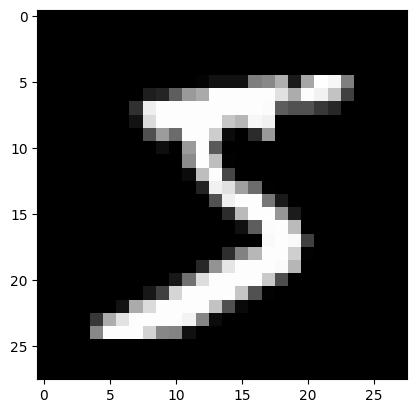

In [ ]:
plt.imshow(x_train[0], cmap='gray')

In [ ]:
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)



1.   Layer One:

      *   Total Neurons = 128
      *   Total Features = 784
      *   Each Neuron has one bias
      *   Each Feature is connected to each Neuron in the first layer
      *   784 (Features)x128 (Neurons) + 128 (Biases) = 100480 param#

2.   Layer Two:
      *   Total Neurons = 32
      *   Total Weights = 128
      *   Each Neuron has one bias
      *   Each Weight is connected to each Neuron in the second layer
      *   128 (Weights)x32 (Neurons) + 32 (Biases) = 4128 Param#

3.   Layer Three
      *   Total Neurons = 10
      *   Total Weights = 32
      *   Each Neuron has one bias
      *   Each Weight is connected to each Neuron in the second layer
      *   32 (Weights)x10 (Neurons) + 10 (Biases) = 330 Param#

***Total Params = 100480 + 4128 + 330 = 104938***

Categorical Crossentropy: Crossentropy is a loss function used in classification tasks. It measures the dissimilarity between the true distribution and the predicted distribution of class labels. For categorical crossentropy, the true distribution is represented as a one-hot encoded vector, where the index corresponding to the true class is 1, and all other indices are 0.

Sparse Categorical Crossentropy: In some cases, your labels might not be one-hot encoded vectors but instead represented as integers. For example, if you have 3 classes, the labels could be 0, 1, or 2. In such cases, you use sparse categorical crossentropy as the loss function. It essentially does the same thing as categorical crossentropy but accepts integer labels directly instead of one-hot encoded vectors.

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8480 - loss: 0.5075 - val_accuracy: 0.9544 - val_loss: 0.1564
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9639 - loss: 0.1249 - val_accuracy: 0.9659 - val_loss: 0.1109
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9752 - loss: 0.0804 - val_accuracy: 0.9712 - val_loss: 0.0976
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9839 - loss: 0.0533 - val_accuracy: 0.9719 - val_loss: 0.0943
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9872 - loss: 0.0437 - val_accuracy: 0.9689 - val_loss: 0.1089
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.9756 - val_loss: 0.0902
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9912 - loss: 0.0265 - val_accuracy: 0.9737 - val_loss: 0.1017
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9919 - loss: 0.0242

In [ ]:
y_prob = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_prob[0]

array([9.6863208e-13, 2.4808557e-15, 1.1435850e-12, 5.1858327e-09,
       6.4463845e-19, 1.0285991e-12, 1.0604225e-20, 9.9999994e-01,
       1.7415892e-15, 6.3830491e-10], dtype=float32)

In [ ]:
y_pred = y_prob.argmax(axis=1)

In [ ]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [ ]:
accuracy_score(y_test, y_pred)

0.9742

Text(0.5, 0, 'Epoch')

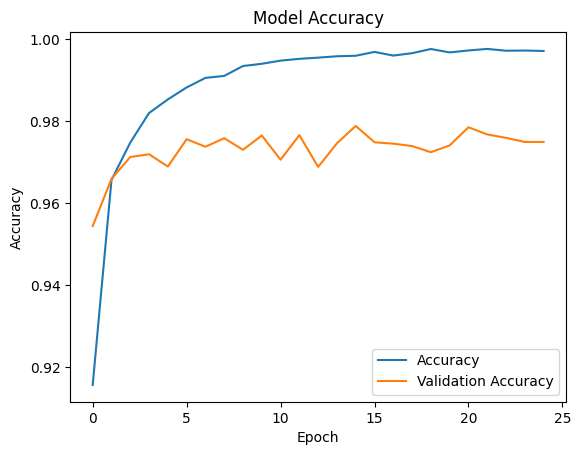

In [ ]:
plt.plot(history.history['accuracy'], label = "Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

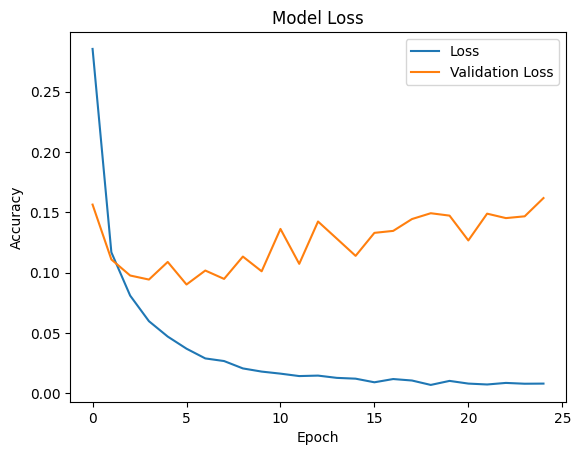

In [ ]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

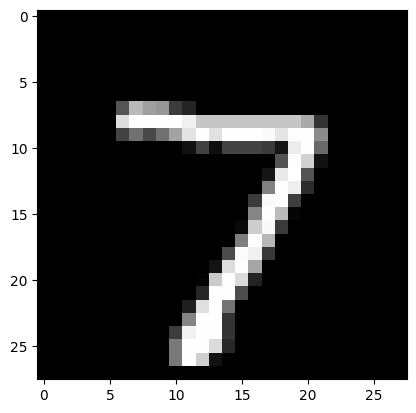

In [ ]:
plt.imshow(x_test[0], cmap='gray')

In [ ]:
model.predict(x_test[0].reshape(1, 28, 28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[9.6863218e-13, 2.4808560e-15, 1.1435829e-12, 5.1858233e-09,
        6.4463850e-19, 1.0286011e-12, 1.0604226e-20, 1.0000000e+00,
        1.7415761e-15, 6.3830374e-10]], dtype=float32)

In [ ]:
model.predict(x_test[0].reshape(1, 28, 28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([7])

In [ ]:
df = pd.read_csv('/content/iris.csv')

In [ ]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

In [ ]:
y = pd.get_dummies(y, prefix='species')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(4,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.1159 - loss: 1.1086 - val_accuracy: 0.5417 - val_loss: 1.0328
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4492 - loss: 1.0170 - val_accuracy: 0.7083 - val_loss: 0.9639
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6862 - loss: 0.9362 - val_accuracy: 0.8333 - val_loss: 0.9012
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6797 - loss: 0.8654 - val_accuracy: 0.9167 - val_loss: 0.8459
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7917 - loss: 0.8171 - val_accuracy: 0.9167 - val_loss: 0.7945
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8086 - loss: 0.7518 - val_accuracy: 0.8750 - val_loss: 0.7467
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8229 - loss: 0.7179 - val_accuracy: 0.8750 - val_loss: 0.7018
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8620 - loss: 0.6540 - val_accuracy: 0.8750 - val_loss: 0.6593

In [ ]:
y_prob = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [ ]:
y_prob[0]

array([0.01162068, 0.8215051 , 0.16687414], dtype=float32)

In [ ]:
y_pred = y_prob.argmax(axis=1)

In [ ]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
accuracy_score(y_test.values.argmax(axis=1), y_pred)

1.0

Text(0.5, 0, 'Epoch')

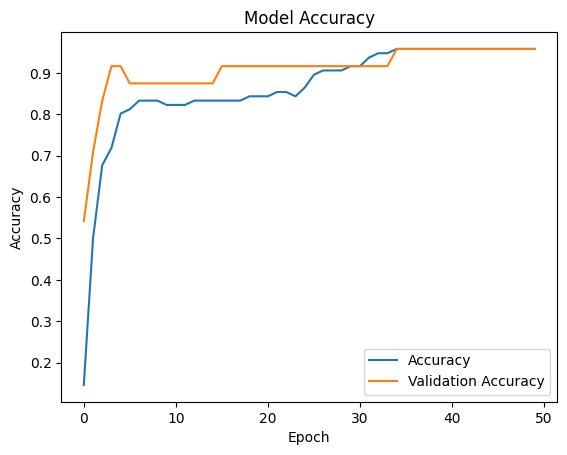

In [ ]:
plt.plot(history.history['accuracy'], label = "Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

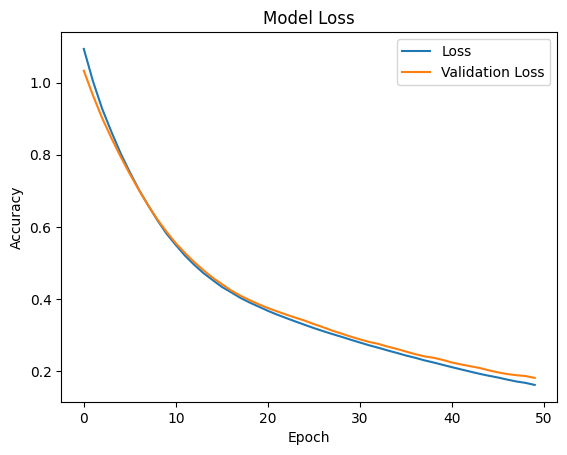

In [ ]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')